# Target Generation & Hyperparameter Optimization
**Goal:** Identify the optimal labels for training by simulating millions of trades across different parameter sets.
**Key Operations:**
1.  **Swing Detection:** Identifying market swings using `build_signal_per_day`.
2.  **Simulation:** Using `simulate_trading` to test stop-losses, take-profits, and directional signals.
3.  **Optimization:** Using Optuna's **Multivariate TPE** to find the highest reward-to-risk configuration.
**Output:** Saves the best performing parameters to `best_params_target.json`.

In [1]:
# --- SYSTEM PURGE & IMPORTS ---
%reset -f

import gc
import torch
import math
import pandas as pd
import numpy as np
import optuna
import importlib
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from optuna.samplers import TPESampler

# 1. Clear GPU/CPU memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 2. Import Custom Libraries
from libs import preps, opts, params, feats, strats

# 3. Handle Reloads
importlib.reload(preps)
importlib.reload(opts)
importlib.reload(params)
importlib.reload(feats)
importlib.reload(strats)

# 4. Standardize Display
pd.set_option('display.max_columns', None)
plt.ioff() # Prevent thousands of plots from popping up during Optuna

print(f"🚀 Environment Ready. Sampler initialized for {params.ticker}")

🚀 Environment Ready. Sampler initialized for AAPL


✅ Data Loaded: 350711 rows ready for Optuna.


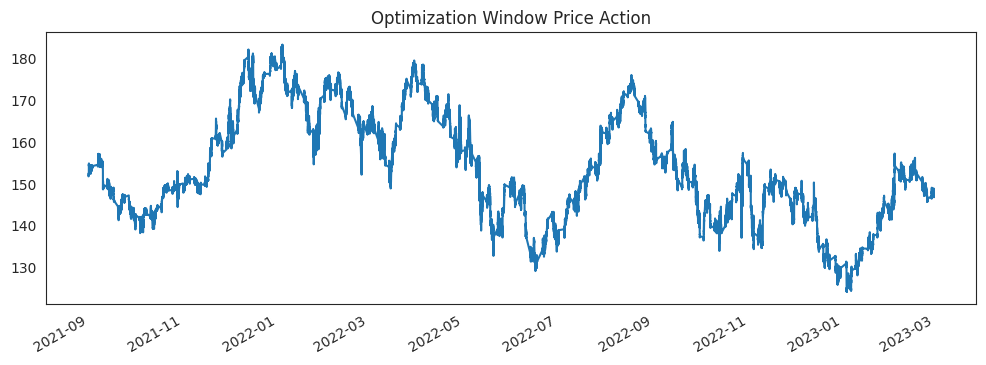

,open,high,low,close,volume,trade_count,vwap,ask,bid,atr_21,adx_21,rsi_21,vwap_ohlc_close_session
2021-09-01 07:00:00,152.340,152.400,152.200,152.310,2052.0,79.0,152.343289,152.3405,152.2795,0.039270,15.994430,88.907688,152.310000
2021-09-01 07:01:00,152.310,152.310,152.310,152.310,1163.0,12.0,152.310000,152.3405,152.2795,0.037400,18.870155,88.907688,152.310000
2021-09-01 07:02:00,152.300,152.300,152.300,152.300,900.0,32.5,152.300000,152.3305,152.2695,0.036095,21.475888,87.281932,152.307813
2021-09-01 07:03:00,152.290,152.290,152.290,152.290,637.0,53.0,152.290000,152.3205,152.2595,0.034852,23.822296,85.637673,152.305425
2021-09-01 07:04:00,152.310,152.310,152.290,152.290,582.0,20.0,152.298281,152.3205,152.2595,0.034145,26.103236,85.637673,152.303742
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-28 23:55:00,146.925,146.925,146.925,146.925,420.0,15.5,146.925000,146.9544,146.8956,0.029606,18.549510,43.468587,147.712166
2023-02-28 23:56:00,146.890,146.890,146.890,146.890,296.0,14.0,146.890000,146.9194,146.8606,0.029863,18.536802,40.493756,147.712162
2023-02-28 23:57:00,146.910,146.910,146.910,146.910,326.0,20.0,146.910000,146.9394,146.8806,0.029393,18.283993,42.840815,147.712158
2023-02-28 23:58:00,146.900,146.920,146.900,146.900,7297.0,29.0,146.900371,146.9294,146.8706,0.028946,18.043223,41.971700,147.712062


In [2]:
col_signal = "targ_signal"

cols_needed = [
    "open", "high", "low", "close", "volume", "trade_count", "vwap", "ask", "bid",
    params.col_atr_tick, params.col_adx_tick, params.col_rsi_tick, params.col_vwap_tick,
]

df_inds = pd.read_parquet(params.indunsc_parquet, columns=cols_needed)

# Filter for the optimization window (Localizing to UTC for consistency)
df_inds.index = pd.to_datetime(df_inds.index).tz_localize(None)
df_inds = df_inds[(df_inds.index >= params.start_date_sim) & (df_inds.index < params.end_date_sim)]

print(f"✅ Data Loaded: {len(df_inds)} rows ready for Optuna.")

plt.figure(figsize=(12, 4))
df_inds['close'].plot(title="Optimization Window Price Action")
plt.show()

df_inds

In [3]:
# 'min_prof_thr': (0.05121694481444561, 0.0540030551855544),
#  'max_down_prop': (0.6061460846109266, 0.6528539153890733),
#  'gain_tightfact': (3.413540213653459, 3.906769786346541),
#  'tau_time': (48.68093278481928, 56.27504721518072),
#  'tau_dur': (63.226961893902214, 96.20824810609777),
#  'thresh_choice': {'categorical': ['median_nonzero']},
#  'rsi_min_thresh': (100, 100),
#  'rsi_max_thresh': (0, 0),
#  'adx_thresh': (14.997572471754179, 15.010627528245823),
#  'trailstop_pct': (0.5514958648622245, 1.1971241351377757),
#  'atr_mult': (0.9825906210150942, 1.0213893789849056),
#  'vwap_atr_mult': (-26.18259943397927, -21.987110566020732),
#  'buy_factor': (4.567450915287415, 5.7567990847125845),
#  'sell_factor': (3.100200713316168, 5.770769286683832)}

In [4]:
def objective(trial: optuna.Trial) -> float:
    # --- 1. Swing Detection (Oracle) ---
    min_prof_thr    = trial.suggest_float("min_prof_thr", 0.02, 0.04)      # Min 0.02 (ML Predictability)
    max_down_prop   = trial.suggest_float("max_down_prop", 0.3, 0.6)      
    gain_tightfact  = trial.suggest_float("gain_tightfact", 1.0, 2.5)    
    tau_time        = trial.suggest_float("tau_time", 30.0, 50.0)
    tau_dur         = trial.suggest_float("tau_dur", 20.0, 40.0)

    # --- 2. Thresholding Logic ---
    thresh_type = trial.suggest_categorical("thresh_type", [
        "numeric", "median_nonzero", "mean_nonzero", "p95", "roll_median"
    ])

    if thresh_type == "numeric":
        thresh_mode = trial.suggest_float("thresh_numeric_val", 0.01, 1.5)
        thresh_window = None
    else:
        thresh_mode = thresh_type
        thresh_window = trial.suggest_int("thresh_window", 50, 1000) if "roll" in thresh_type else None

    # --- 3. Strategy Filters ---
    rsi_min_thresh  = trial.suggest_float("rsi_min_thresh", 100.0, 100.0)
    rsi_max_thresh  = trial.suggest_float("rsi_max_thresh", 0.0, 0.0)
    
    adx_thresh      = trial.suggest_float("adx_thresh", 15.0, 15.0)       # Min 15.0 (ML Predictability)
    trailstop_pct   = trial.suggest_float("trailstop_pct", 0.5, 1.5)      # Min 0.02 (Tick Size)
    atr_mult        = trial.suggest_float("atr_mult", 1.0, 1.0)           # Min 1.0 (ML Predictability)
    
    vwap_atr_mult   = trial.suggest_float("vwap_atr_mult", -30.0, -20.0)
    
    # --- 4. Position Sizing ---
    buy_factor      = trial.suggest_float("buy_factor", 4.0, 6.0)
    sell_factor     = trial.suggest_float("sell_factor", 3.0, 6.0)

    print("-" * 160)
    print("Params => " + "; ".join(f"{k}={v}" for k, v in dict(trial.params).items()))

    # 2. Build signal and apply thresholds (Pre-processing)
    df_build = preps.build_signal_per_day(
        df              = df_inds.copy(),
        min_prof_thr    = min_prof_thr,
        max_down_prop   = max_down_prop,
        gain_tightfact  = gain_tightfact,
        tau_time        = tau_time,
        tau_dur         = tau_dur,
        col_close       = "close",
    )

    df_thresh = preps.apply_thresholds_per_day(
        df              = df_build,
        thresh_mode     = thresh_mode,
        thresh_window   = thresh_window,
        col_signal      = col_signal
    )

    # Reset global state for the trial
    start_ask = float(df_thresh["ask"].iloc[0])
    strats.reset_globals(start_ask)

    groups = list(df_thresh.groupby(df_thresh.index.normalize()))
    pbar = tqdm(groups, total=len(groups), desc=f"Trial {trial.number}", leave=True)
    acc = opts.TrialAccumulator(trial, pbar, report_interval=report_interval, prun_perc=prun_perc)
    
    for step, (day, df_day) in enumerate(pbar, 1):
        # 3. Call generate_actions with the full parameter set
        df_actions = strats.generate_actions(
            df              = df_day,
            col_signal      = col_signal,
            sign_thresh     = "signal_thresh",
            col_atr         = params.col_atr_tick,
            col_adx         = params.col_adx_tick,
            col_rsi         = params.col_rsi_tick,
            col_vwap        = params.col_vwap_tick,
            rsi_min_thresh  = rsi_min_thresh,
            rsi_max_thresh  = rsi_max_thresh,
            adx_thresh      = adx_thresh,
            trailstop_pct   = trailstop_pct,
            atr_mult        = atr_mult,
            vwap_atr_mult   = vwap_atr_mult,
            buy_factor      = buy_factor,
            sell_factor     = sell_factor,
            col_close       = "close"
        )

        # 4. Call simulate_trading with ONLY day and df as required
        sim_results = strats.simulate_trading(
            day             = day,
            df              = df_actions
        )

        acc.process(sim_results, step, parse_eq_value_callable=strats._parse_eq_value)
        
        if trial.should_prune():
            del df_actions, sim_results, df_thresh, groups  # Added this
            raise optuna.exceptions.TrialPruned()

        del df_actions, sim_results

    final_val = acc.finalize()
    del df_thresh, groups
    gc.collect() 
    return final_val

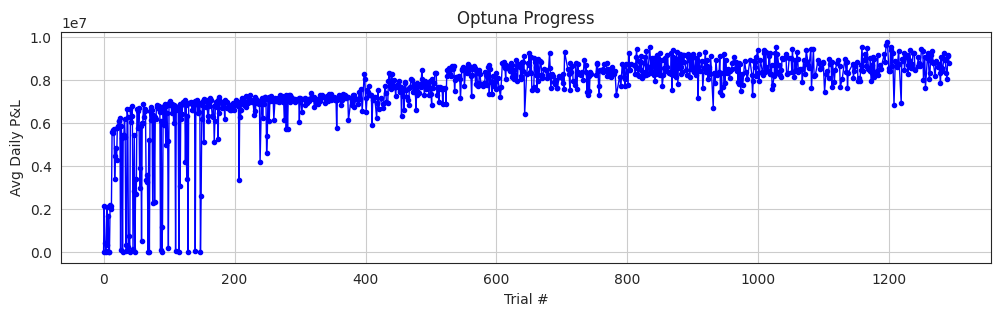

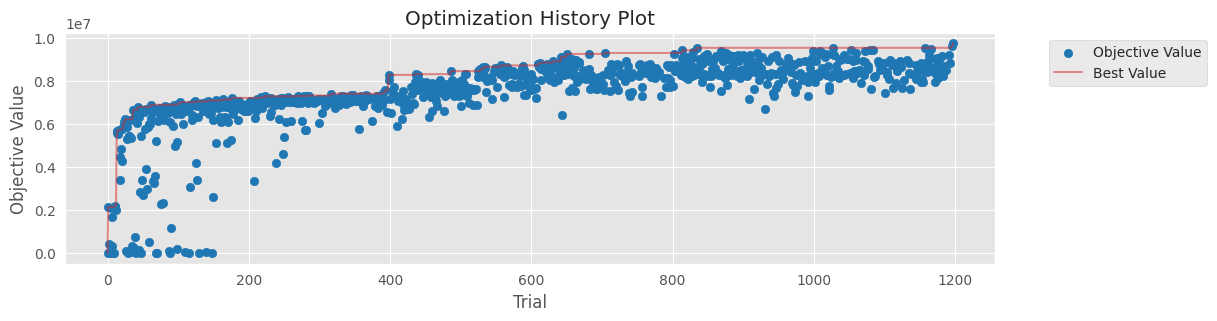

----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.030605786837598827; max_down_prop=0.5541379970128741; gain_tightfact=1.7882569850588523; tau_time=44.411274437043005; tau_dur=39.46220965964379; thresh_type=p95; rsi_min_thresh=100.0; rsi_max_thresh=0.0; adx_thresh=15.0; trailstop_pct=1.0438396457641845; atr_mult=1.0; vwap_atr_mult=-24.760425637749698; buy_factor=5.756007459410009; sell_factor=3.8625901358945725


Building Oracle Signal:   0%|          | 0/375 [00:00<?, ?it/s]

Thresh per day:   0%|          | 0/375 [00:00<?, ?it/s]

Trial 0: 100%|██████████| 375/375 [00:21<00:00, 17.21it/s]


[Results] mean_pnl:10636.0008 mean_bh:-8.7491 mean_excess:10644.7499 improv_vs_bh:121666.97%
Action counts: {'Buy': 1770, 'Sell': 1157, 'Hold': 347784}
Best trial is: 0 with best_val: 10644.7499
[save_results] wrote optuna_results/AAPL_10644.7499_target.csv
[save_best_json] wrote optuna_results/AAPL_10644.7499_target.json
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.020951841459635356; max_down_prop=0.47463571196519094; gain_tightfact=2.3449514077112603; tau_time=42.76226564783909; tau_dur=38.60968145111033; thresh_type=mean_nonzero; rsi_min_thresh=100.0; rsi_max_thresh=0.0; adx_thresh=15.0; trailstop_pct=1.2364830695065385; atr_mult=1.0; vwap_atr_mult=-20.194692877120353; buy_factor=4.2505822104873685; sell_factor=4.526683842103845


...

[PRUNE] value=1558.330793 thr=23995.985087
[Results] mean_pnl:1658.2723 mean_bh:99.9415 mean_excess:1558.3308 improv_vs_bh:1559.24%
Action counts: {'Buy': 852, 'Sell': 439, 'Hold': 139022}
Best trial is: 1197 with best_val: 9766038.6434
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => min_prof_thr=0.022520882211277134; max_down_prop=0.5905692497462841; gain_tightfact=1.22994012942204; tau_time=42.9265913620679; tau_dur=25.555058621290847; thresh_type=mean_nonzero; rsi_min_thresh=100.0; rsi_max_thresh=0.0; adx_thresh=15.0; trailstop_pct=1.042785641008327; atr_mult=1.0; vwap_atr_mult=-23.845414104816612; buy_factor=5.207563129036466; sell_factor=4.853427063630884


Building Oracle Signal:   0%|          | 0/375 [00:00<?, ?it/s]

Thresh per day:   0%|          | 0/375 [00:00<?, ?it/s]

Trial 1293:  17%|█▋        | 62/375 [00:03<00:19, 15.66it/s]


KeyboardInterrupt: 

In [5]:
report_interval   = 50
prun_perc         = 80
n_startup_trials  = 150
n_trials          = 3000

opts.init_optuna_displays()
optuna.logging.set_verbosity(optuna.logging.ERROR)

# sampler = optuna.samplers.TPESampler(n_startup_trials=250, multivariate=True)

pruner  = optuna.pruners.PercentilePruner(
    percentile=prun_perc, 
    n_startup_trials=n_startup_trials, 
    n_warmup_steps=math.ceil(math.ceil(len(list(df_inds.groupby(df_inds.index.normalize()))) / report_interval) * 0.3)
)

study = optuna.create_study(pruner=pruner, 
                            # sampler=sampler, 
                            direction="maximize")

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[opts.plot_callback, opts.short_log_callback, 
               opts.make_save_results_callback("target"), 
               opts.make_save_best_json_callback("target")],
    gc_after_trial=True
)

NameError: name 'df_all_features' is not defined